In [1]:
# Importing Libraries

import pandas as pd
import numpy as np

# Visualization Libraries

#!pip install pydot
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

# Evaluation Libraries

from sklearn. metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [2]:
# Deep Learning Libraries

#!pip install tensorflow==2.7.0
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
from keras.wrappers.scikit_learn import KerasClassifier

In [3]:
# Loading the dataset from MNIST

(x_train_digit,y_train_digit),(x_test_digit,y_test_digit)=mnist.load_data() # MNIST is readily available dataset from Keras, containing 60,000 images with 10,000 testsets of gray scale images. These images are hand-written numbers from 0 to 9.

In [4]:
print('x_train_digit.shape = ',x_train_digit.shape)
print('x_train_digit[0].shape = ',x_train_digit[0].shape)
print('y_train_digit.shape = ',y_train_digit.shape)
print()
print('x_test_digit.shape = ',x_test_digit.shape)
print('y_test_digit.shape = ',y_test_digit.shape)

x_train_digit.shape =  (60000, 28, 28)
x_train_digit[0].shape =  (28, 28)
y_train_digit.shape =  (60000,)

x_test_digit.shape =  (10000, 28, 28)
y_test_digit.shape =  (10000,)


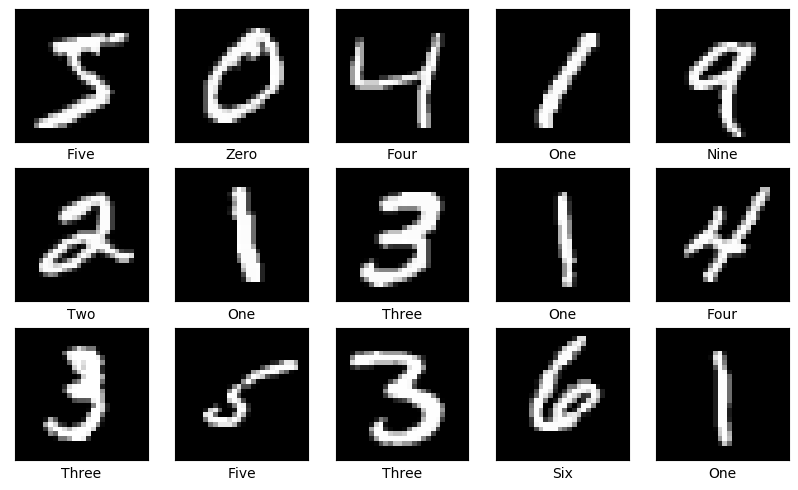

In [5]:
# Dataset Visualization

col_names=['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']
plt.figure(figsize=(10,10))
for i in range(15):           # Number of images to be displayed
    plt.subplot(5,5,i+1)      # 5 rows, 5 columns and position
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_digit[i],cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [6]:
# Input Pre-processing: 
# Converting 2D data into a single data: First input data has 28 rows and 28 cols = 28*28=784

x_train_digit=x_train_digit.reshape(60000,784)
x_test_digit=x_test_digit.reshape(10000,784)
x_train_digit.shape,x_test_digit.shape

((60000, 784), (10000, 784))

In [7]:
# Output Pre-processing:
# Converting the numerical data into categorical data using One-Hot-Encoding method

y_test_digit.shape
y_train_digit=to_categorical(y_train_digit,num_classes=10)
y_test_digit=to_categorical(y_test_digit,num_classes=10)

In [8]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [9]:
# Creating Base Neural Network

model=keras.Sequential([layers.Dense(256,activation='relu',input_shape=(784,)),layers.Dense(64,activation='relu'),layers.Dense(64,activation='relu'),layers.Dense(10,activation='sigmoid'),])

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 222,218
Trainable params: 222,218
Non-trainable params: 0
_________________________________________________________________


In [11]:
# Compiling the model

model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])
history=model.fit(x_train_digit,y_train_digit,batch_size=100,epochs=10,validation_data=(x_test_digit,y_test_digit))

Epoch 1/10
600/600 [==============================] - 2s 3ms/step - loss: 1.4176 - accuracy: 0.8299 - val_loss: 0.3701 - val_accuracy: 0.9053
Epoch 2/10
600/600 [==============================] - 1s 2ms/step - loss: 0.2717 - accuracy: 0.9277 - val_loss: 0.3074 - val_accuracy: 0.9274
Epoch 3/10
600/600 [==============================] - 2s 3ms/step - loss: 0.1937 - accuracy: 0.9476 - val_loss: 0.2039 - val_accuracy: 0.9523
Epoch 4/10
600/600 [==============================] - 2s 3ms/step - loss: 0.1512 - accuracy: 0.9586 - val_loss: 0.1966 - val_accuracy: 0.9542
Epoch 5/10
600/600 [==============================] - 2s 3ms/step - loss: 0.1287 - accuracy: 0.9638 - val_loss: 0.2266 - val_accuracy: 0.9471
Epoch 6/10
600/600 [==============================] - 2s 3ms/step - loss: 0.1270 - accuracy: 0.9659 - val_loss: 0.1559 - val_accuracy: 0.9620
Epoch 7/10
600/600 [==============================] - 2s 3ms/step - loss: 0.1038 - accuracy: 0.9715 - val_loss: 0.1698 - val_accuracy: 0.9594
Epoch 

In [12]:
# Prediction

y_pred=model.predict(x_test_digit)

In [13]:
y_predict=np.argmax(y_pred,axis=1)
y_predict

array([2, 2, 1, ..., 4, 3, 6], dtype=int64)

In [14]:
y_test_digit_eval=np.argmax(y_test_digit,axis=1)
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

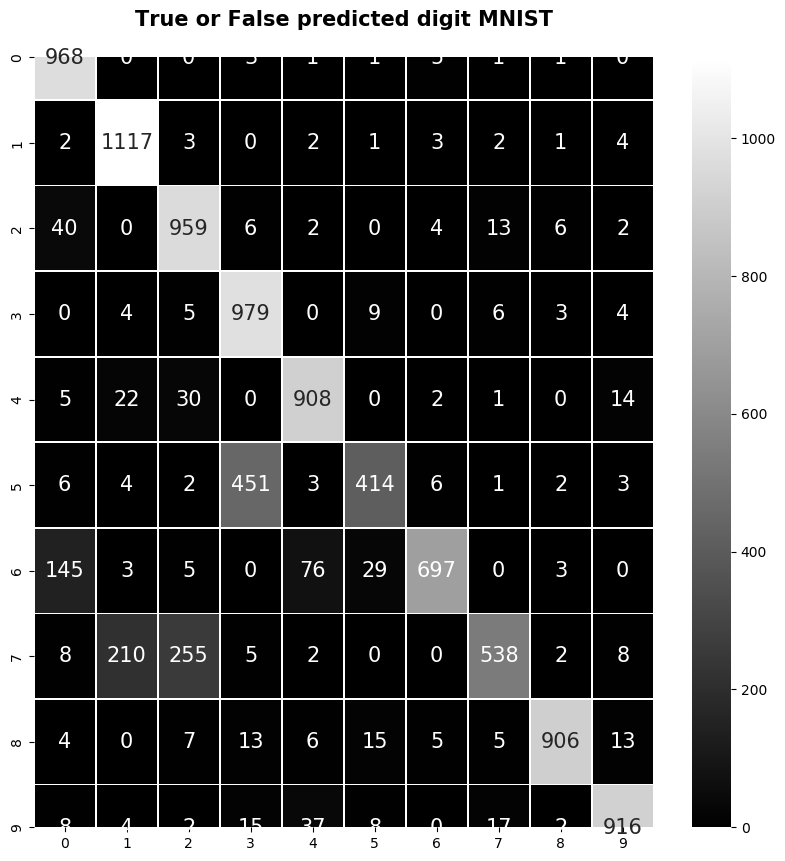

In [15]:
# Confusion Matrix

con_mat=confusion_matrix(y_test_digit_eval,y_predict)
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [16]:
# Classification Report

from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval,y_predict))

              precision    recall  f1-score   support

           0       0.82      0.99      0.89       980
           1       0.82      0.98      0.89      1135
           2       0.76      0.93      0.83      1032
           3       0.67      0.97      0.79      1010
           4       0.88      0.92      0.90       982
           5       0.87      0.46      0.60       892
           6       0.97      0.73      0.83       958
           7       0.92      0.52      0.67      1028
           8       0.98      0.93      0.95       974
           9       0.95      0.91      0.93      1009

    accuracy                           0.84     10000
   macro avg       0.86      0.83      0.83     10000
weighted avg       0.86      0.84      0.83     10000



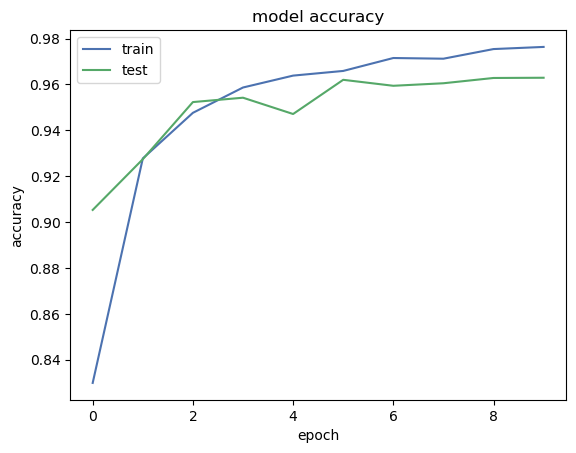

In [17]:
# model.fit Visualization to study the model learning process

#history.history['accuracy']
#history.history['val_accuracy']
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.show()

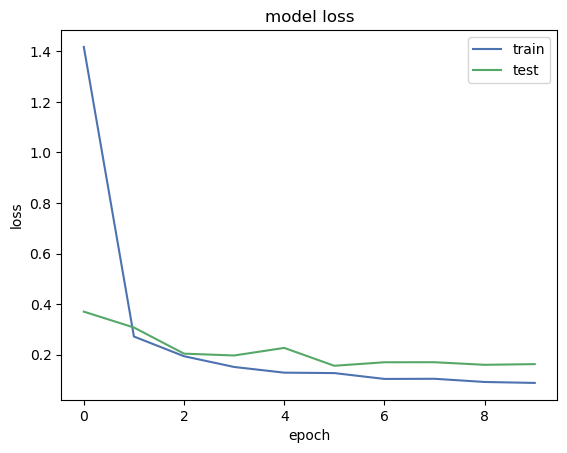

In [18]:
# Visualization for Loss Function

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='best')
plt.show()

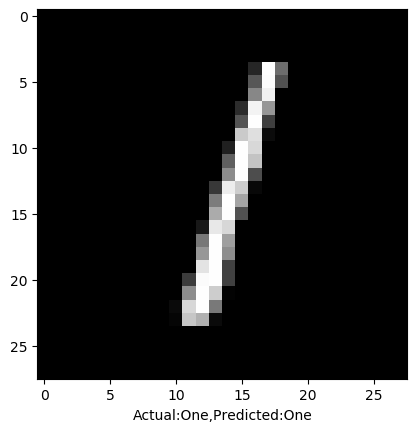

In [19]:
# Deployment Phase

y_predict_single=model.predict(x_test_digit[[2]])
y_predicts_single=np.argmax(y_predict_single,axis=1)
y_test_digit_eval=np.argmax(y_test_digit,axis=1)
col_names=['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']
plt.imshow(x_test_digit[2].reshape(28,28),cmap='gray')
plt.xlabel('Actual:{},Predicted:{}'.format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()